# 1. Simple Linear Regression

## House Price Prediction

    Size_sqft   Price
0         600   90000
1         750  110000
2         800  120000
3         900  135000
4        1000  150000
5        1100  165000
6        1200  180000
7        1300  200000
8        1400  210000
9        1500  225000
10       1600  240000
11       1700  250000
12       1800  265000
13       1900  280000
14       2000  300000
Predicted price for 2100 sqft :  [312399.41655524]


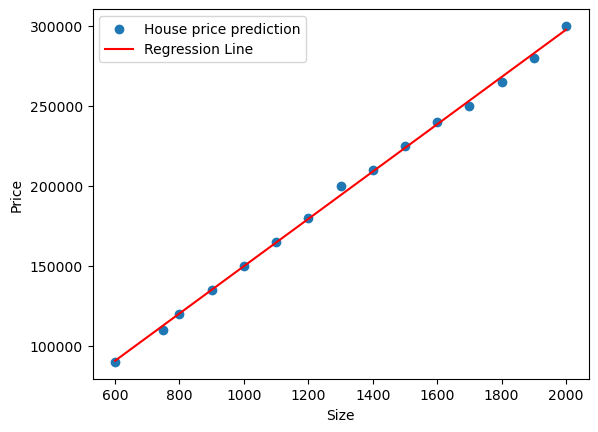

Coefficient (Slope): 147.78169442080954
Intercept: 2057.8582715448865


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

data1 = {
    'Size_sqft': [600, 750, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000],
    'Price': [90000, 110000, 120000, 135000, 150000, 165000, 180000, 200000, 210000, 225000, 240000, 250000, 265000, 280000, 300000]
}

df1 = pd.DataFrame(data1)
print(df1)

# Plot scatter graph

plt.scatter(df1.Size_sqft,df1.Price, label = 'House price prediction' )

# Train linear regression model
x = df1[['Size_sqft']].values # Features must be 2D
y = df1['Price'].values
model = LinearRegression()
model.fit(x,y)

# Predict price for 2100 sqft
prediction = model.predict([[2100]])
print("Predicted price for 2100 sqft : ", prediction)

# Plot regression line
plt.plot(df1.Size_sqft, model.predict(x), color='red', label='Regression Line')
plt.xlabel('Size')
plt.ylabel('Price')
plt.legend()
plt.show()

# Find model coefficient and intercept
print(f"Coefficient (Slope): {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")

## 2: Advertising Budget vs Sales

    Advertising_budget  Sales
0                    5     25
1                    7     30
2                    8     34
3                   10     40
4                   12     48
5                   15     55
6                   18     60
7                   20     70
8                   22     75
9                   25     82
10                  27     90
11                  30    100
Predicted value of sales when budget = 35 is [113.22358296]


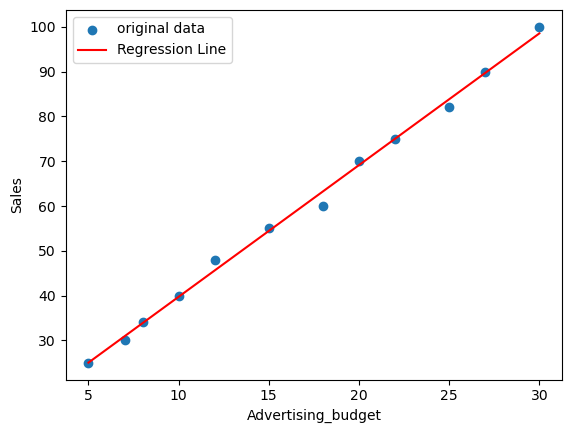

Coefficient (Slope): 2.9397420613417165
Intercept: 10.33261081608321


In [3]:
import pandas as pd
import matplotlib.pyplot as plt


data = {
    'Advertising_budget':[5, 7, 8, 10, 12, 15, 18, 20, 22, 25, 27, 30],
    'Sales':[25, 30, 34, 40, 48, 55, 60, 70, 75, 82, 90, 100]
}
df = pd.DataFrame(data)
print(df)

# 1.Train regression model
x = df[['Advertising_budget']].values
y = df['Sales'].values
model = LinearRegression()
model.fit(x, y)

# 2. Predict sales when budget = 35
result = model.predict([[35]])
print(f"Predicted value of sales when budget = 35 is {result}")

# 3. Plot regression line
plt.scatter(x,y, label='original data')
plt.plot(x,model.predict(x), color = 'red', label = 'Regression Line')
plt.xlabel('Advertising_budget')
plt.ylabel('Sales')
plt.legend()  # used display labels
plt.show()

# 4. Interpret slope value
print(f"Coefficient (Slope): {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")

# 2. Polynomial Regression

## 1. Position Level vs Salary

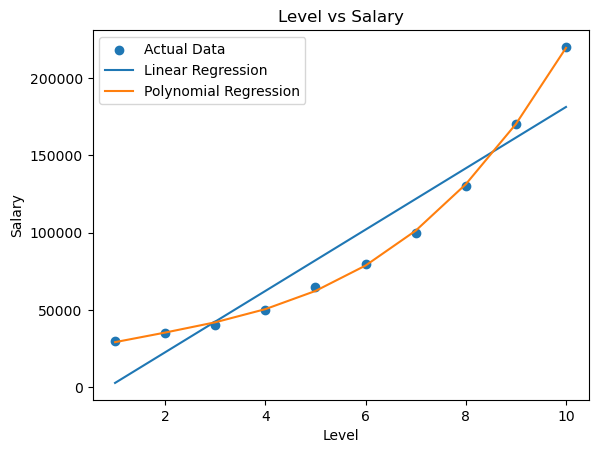

salary for Level 11 (by LinearRegression): [201000.]
salary for Level 11 (by PolynomialLinearRegression degree = 3): [280333.33333333]


In [4]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
import matplotlib.pyplot as plt


data = {
    'Level':[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Salary':[30000, 35000, 40000, 50000, 65000, 80000, 100000, 130000, 170000, 220000]
}

df = pd.DataFrame(data)

# 1. Train linear regression
x = df[['Level']].values
y = df['Salary'].values

lr = LinearRegression()
lr.fit(x,y)

# 2. Train polynomial regression (degree=2 or 3)
pr = PolynomialFeatures(degree=3)

x_poly = pr.fit_transform(x)

lr2 = LinearRegression()
lr2.fit(x_poly, y)

# 3. Plot both models
plt.scatter(x, y, label = 'Actual Data')
plt.plot(x, lr.predict(x), label = 'Linear Regression')
plt.plot(x, lr2.predict(pr.fit_transform(x)), label = 'Polynomial Regression')
plt.legend()
plt.xlabel('Level')
plt.ylabel('Salary')
plt.title('Level vs Salary')
plt.show()

# 4. Predict salary for Level 11
# 5. Compare results
print(f"salary for Level 11 (by LinearRegression): { lr.predict([[11]]) }")
print(f"salary for Level 11 (by PolynomialLinearRegression degree = 3): { lr2.predict(pr.fit_transform([[11]])) }")


## 2: Temperature vs Ice Cream Sales

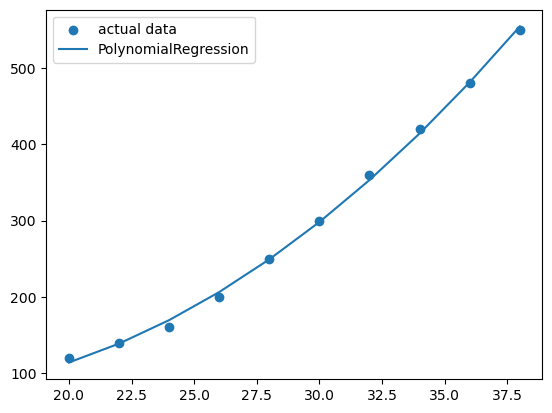

Predicted sales for Temperature = 40°C is [634.]


In [5]:
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt


data = {
    'Temperature':[20, 22, 24, 26, 28, 30, 32, 34, 36, 38],
    'Sales':[120, 140, 160, 200, 250, 300, 360, 420, 480, 550]
}
df = pd.DataFrame(data)

x = df[['Temperature']].values
y = df['Sales'].values

# 1. Train polynomial regression
pr = PolynomialFeatures(degree = 2)
x_poly = pr.fit_transform(x)

lr = LinearRegression()
lr.fit(x_poly, y)

# 2. Plot polynomial curve
plt.scatter(x,y,label='actual data')
plt.plot(x, lr.predict(x_poly), label = 'PolynomialRegression')
plt.legend()
plt.show()

# 3. Predict sales for Temperature = 40°C
print(f"Predicted sales for Temperature = 40°C is { lr.predict(pr.fit_transform([[40]])) }")

# 3. Multiple Linear Regression
## Project 1: Student Performance Prediction

In [6]:
import pandas as pd
from sklearn.linear_model import LinearRegression

data = {
    'Study_hours':[2, 3, 3, 4, 5, 6, 6, 7, 8, 9, 10],
    'Sleep_hours':[6, 7, 6, 7, 6, 7, 8, 7, 7, 8, 8],
    'Attendance':[70, 75, 80, 85, 88, 90, 92, 94, 95, 97, 98],
    'Score':[55, 60, 62, 68, 72, 78, 82, 86, 90, 94, 96]
}

df = pd.DataFrame(data)

# Features (X) and Target (y)
x = df[['Study_hours', 'Sleep_hours', 'Attendance']]
y = df['Score']

# 1. Train multiple regression model
model = LinearRegression()
model.fit(x,y)

# 2. Predict score for
# Study_hours = 7
# Sleep_hours = 7
# Attendance = 90

# print(f"Predicted value: { model.predict([[7,7,90]]) }")
new_data = pd.DataFrame([[7, 7, 90]], columns=['Study_hours', 'Sleep_hours', 'Attendance'])
prediction = model.predict(new_data)
print(f"Predicted Score: {prediction[0]:.2f}")

# 3. Display coefficients
coeffs = pd.Series(model.coef_, index=x.columns)
print("\nModel Coefficients:")
print(coeffs)
print(f"Intercept: {model.intercept_:.2f}")

# 4. Interpret which variable influences score most
# Note: In real scenarios, we should scale data first, but with this raw data:
most_influential = coeffs.idxmax()
print(f"\nInterpretation: The variable '{most_influential}' has the highest coefficient,")
print("suggesting it has the strongest positive impact on the score in this model.")



Predicted Score: 82.28

Model Coefficients:
Study_hours    3.479900
Sleep_hours    0.938016
Attendance     0.513743
dtype: float64
Intercept: 5.12

Interpretation: The variable 'Study_hours' has the highest coefficient,
suggesting it has the strongest positive impact on the score in this model.


## 2: House Price Prediction

In [7]:
import pandas as pd
from sklearn.linear_model import LinearRegression

data = {
    'Area':[1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800],
    'Bedrooms':[2, 2, 3, 3, 3, 4, 4, 4, 5, 5],
    'Age':[10, 8, 6, 5, 4, 3, 2, 2, 1, 1],
    'Price':[150000, 180000, 220000, 250000, 280000, 310000, 340000, 370000, 420000, 450000]
}

df = pd.DataFrame(data)

# 1. Train regression model
x = df[['Area', 'Bedrooms', 'Age']]
y = df['Price']
model = LinearRegression()
model.fit(x,y)

# 2. Predict house price for
# Area = 2100
# Bedrooms = 4
# Age = 2

x_pred = pd.DataFrame([[2100, 4, 2]], columns=['Area', 'Bedrooms', 'Age'])
print(f"Predected price of House: {model.predict(x_pred)}")



Predected price of House: [329093.51145038]


# 4. Classification
## 1: Email Spam Detection

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

data = {
    'Message_length': [120, 80, 200, 60, 300, 150, 90, 70, 250, 100, 180, 85],
    'Links': [1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0],
    'Spam': [1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0]
}
df = pd.DataFrame(data)

x = df[['Message_length', 'Links']]
y = df['Spam']

# 1. Split dataset using train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

# 2. Train Logistic Regression model
model = LogisticRegression()
model.fit(x_train,y_train)

# 3. Predict spam messages
y_pred = model.predict(x_test)

# 4. Print predictions
result = pd.DataFrame({
    'Actual':y_test.values,
    'Prediction':y_pred
})
print(result)


   Actual  Prediction
0       1           1
1       0           0
2       1           0
3       1           1


## 2: Loan Approval Prediction

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


data = {
    'Income':[30000, 40000, 50000, 25000, 45000, 32000, 60000, 70000, 20000, 52000],
    'Credit_score':[650, 700, 720, 600, 680, 640, 750, 780, 580, 710],
    'Loan_Approved':[0,1,1,0,1,0,1,1,0,1]
}

df = pd.DataFrame(data)

x = df[['Income', 'Credit_score']]
y = df['Loan_Approved']

# 1. Train classification model
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(x_train,y_train)

# 2. Predict loan approval for
# Income = 48000
# Credit_score = 690

x_pred = pd.DataFrame([[48000,690]], columns=['Income', 'Credit_score'])

y_pred = model.predict(x_pred)
print(y_pred)


[1]


# 5. Evaluation Metrics
## Heart Disease Classification

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
[[5 0]
 [0 5]]


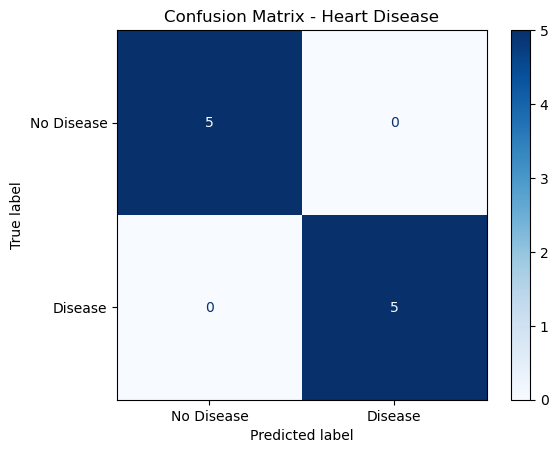

In [11]:
import pandas as pd 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

data = {
    'Age': [45, 50, 30, 25, 60, 55, 35, 40, 65, 28],
    'BP': [130, 140, 120, 110, 150, 145, 125, 128, 155, 115],
    'Cholesterol': [200, 220, 180, 170, 240, 230, 190, 195, 250, 175],
    'Disease': [1, 1, 0, 0, 1, 1, 0, 0, 1, 0]
}

df = pd.DataFrame(data)

# 1. Train classification model
# (Logistic Regression)

x = df[['Age', 'BP', 'Cholesterol']]
y = df['Disease']

model = LogisticRegression()
model.fit(x,y)

# 2. Calculate metrics
y_pred = model.predict(x)

accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")

# 3. Generate Confusion Matrix
cm = confusion_matrix(y, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Heart Disease')
plt.show()